<ipython-input-1-edca4bcf0f6e>:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

dataset_size:
train_dataset: 20000
valid_dataset: 5000
test_dataset: 25000
smaple:
text: The most succinct way to describe Ride With The Devil is with but one word: authenticity. I will not...
label: positive
label distrubitions:
train_dataset - positive(1): 10011
train_dataset - negative(0): 9989
valid_dataset - positive(1): 2489
valid_dataset - negative(0): 2511
test_dataset - positive(1): 12500
test_dataset - negative(0): 12500

TRAIN文本长度统计:
样本数量: 20000
最小长度: 10
最大长度: 1839
平均长度: 233.9
中位数: 174.0
标准差: 174.0
75%分位数: 285.0
95%分位数: 599.0
超过BERT最大长度的比例: 73.76%

VALID文本长度统计:
样本数量: 5000
最小长度: 12
最大长度: 2470
平均长度: 233.5
中位数: 173.0
标准差: 172.7
75%分位数: 283.0
95%分位数: 595.0500000000002
超过BERT最大长度的比例: 74.18%

TEST文本长度统计:
样本数量: 25000
最小长度: 4
最大长度: 2278
平均长度: 228.5
中位数: 172.0
标准差: 168.9
75%分位数: 277.0
95%分位数: 582.0499999999993
超过BERT最大长度的比例: 73.06%

ALL文本长度统计:
样本数量: 50000
最小长度: 4
最大长度: 2470
平均长度: 231.2
中位数: 173.0
标准差: 171.3
75%分位数: 280.0
95%分位数: 590.0
超过BERT最大长度的比例: 73.45%


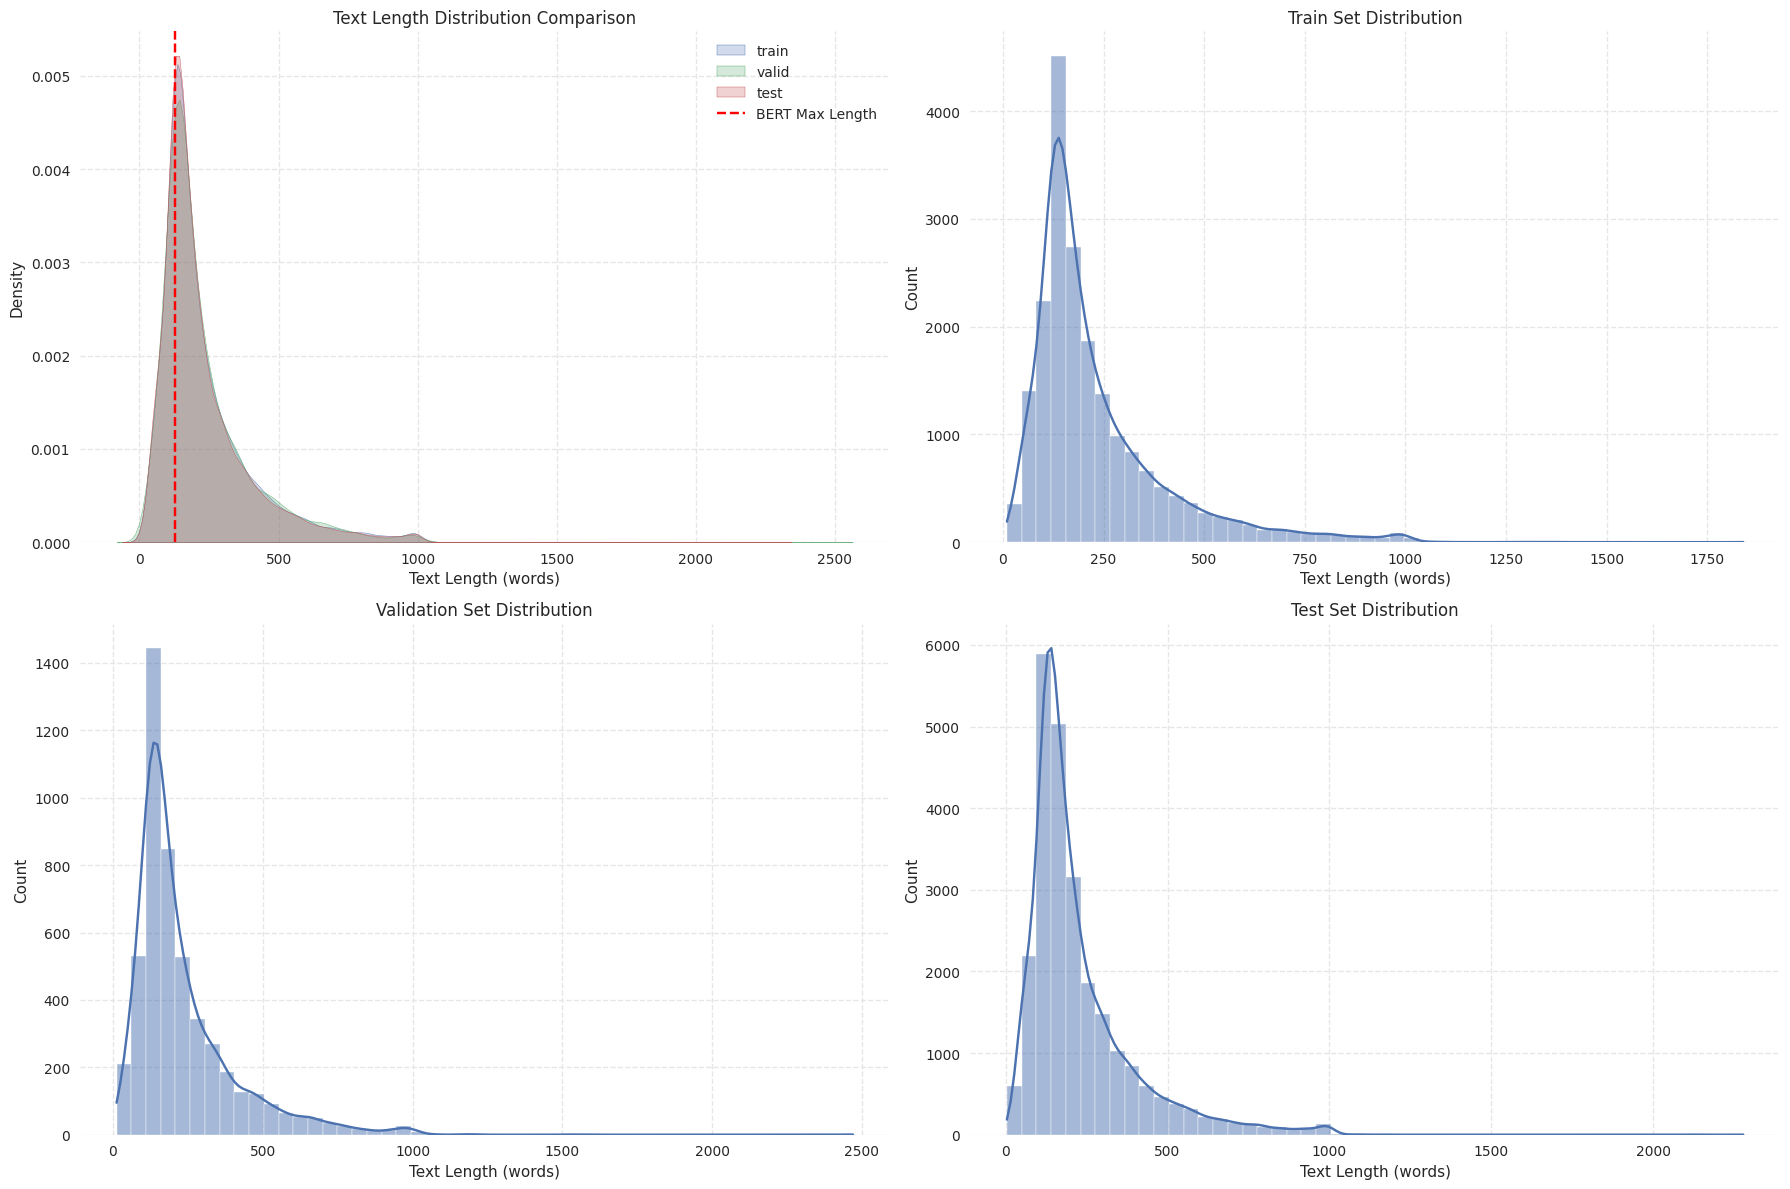

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from datasets import load_dataset, DatasetDict
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning) 
import seaborn as sns
from torch import nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import time
plt.style.use('seaborn')
from tqdm import tqdm

class IMDBDataset(Dataset):
    def __init__(self, dataset, tokenizer, max_length):
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        text = self.dataset[idx]['text']
        label = self.dataset[idx]['label']
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].squeeze()
        attention_mask = encoding['attention_mask'].squeeze()
        label = torch.tensor(label, dtype=torch.long)
        return input_ids, attention_mask, label

def plot_all_distributions(datasets):
    sns.set_style("white")
    plt.figure(figsize=(18, 12), facecolor='white')
    sns.set_style("whitegrid", {
    'axes.facecolor': 'white',
    'grid.color': '.9',
    'grid.linestyle': '--',
    'axes.edgecolor': '.9' 
    })
    plt.subplot(2, 2, 1)
    for name, data in datasets.items():
        sns.kdeplot(data['lengths'], label=name, fill=True)
    plt.title('Text Length Distribution Comparison')
    plt.xlabel('Text Length (words)')
    plt.ylabel('Density')
    plt.legend()
    plt.axvline(x=128, color='red', linestyle='--', label='BERT Max Length')
    plt.legend()
    plt.subplot(2, 2, 2)
    sns.histplot(datasets['train']['lengths'], bins=50, kde=True)
    plt.title('Train Set Distribution')
    plt.xlabel('Text Length (words)')
    plt.subplot(2, 2, 3)
    sns.histplot(datasets['valid']['lengths'], bins=50, kde=True)
    plt.title('Validation Set Distribution')
    plt.xlabel('Text Length (words)')
    plt.subplot(2, 2, 4)
    sns.histplot(datasets['test']['lengths'], bins=50, kde=True)
    plt.title('Test Set Distribution')
    plt.xlabel('Text Length (words)')
    
    plt.tight_layout()
    plt.show()

def print_statistics(name, lengths):
    print(f"\n{name}文本长度统计:")
    print(f"样本数量: {len(lengths)}")
    print(f"最小长度: {min(lengths)}")
    print(f"最大长度: {max(lengths)}")
    print(f"平均长度: {np.mean(lengths):.1f}")
    print(f"中位数: {np.median(lengths)}")
    print(f"标准差: {np.std(lengths):.1f}")
    print(f"75%分位数: {np.percentile(lengths, 75)}")
    print(f"95%分位数: {np.percentile(lengths, 95)}")
    truncated = sum(1 for l in lengths if l > 128)
    print(f"超过BERT最大长度的比例: {truncated/len(lengths):.2%}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = load_dataset('imdb')
train_testvalid = dataset['train'].train_test_split(test_size=0.2)
dataset_dict = DatasetDict({
    'train': train_testvalid['train'],
    'valid': train_testvalid['test'],
    'test': dataset['test']
})
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
max_length = 128

# 创建数据集并收集长度信息
datasets = {
    'train': {'dataset': IMDBDataset(dataset_dict['train'], tokenizer, max_length)},
    'valid': {'dataset': IMDBDataset(dataset_dict['valid'], tokenizer, max_length)},
    'test': {'dataset': IMDBDataset(dataset_dict['test'], tokenizer, max_length)}
}

print("dataset_size:")
train_dataset = IMDBDataset(dataset_dict['train'], tokenizer, max_length)
valid_dataset = IMDBDataset(dataset_dict['valid'], tokenizer, max_length)
test_dataset = IMDBDataset(dataset_dict['test'], tokenizer, max_length)
print(f"train_dataset: {len(train_dataset)}")
print(f"valid_dataset: {len(valid_dataset)}")
print(f"test_dataset: {len(test_dataset)}")
print("smaple:")
print("text:", train_dataset.dataset[0]['text'][:100] + "...")
print("label:", "positive" if train_dataset.dataset[0]['label'] == 1 else "negative")
train_labels = [sample['label'] for sample in train_dataset.dataset]
valid_labels = [sample['label'] for sample in valid_dataset.dataset]
test_labels = [sample['label'] for sample in test_dataset.dataset]
print("label distrubitions:")
print("train_dataset - positive(1):", np.sum(train_labels))
print("train_dataset - negative(0):", len(train_labels) - np.sum(train_labels))
print("valid_dataset - positive(1):", np.sum(valid_labels))
print("valid_dataset - negative(0):", len(valid_labels) - np.sum(valid_labels))
print("test_dataset - positive(1):", np.sum(test_labels))
print("test_dataset - negative(0):", len(test_labels) - np.sum(test_labels))

for name in datasets:
    datasets[name]['lengths'] = [
        len(sample['text'].split()) 
        for sample in datasets[name]['dataset'].dataset
    ]
    print_statistics(name.upper(), datasets[name]['lengths'])
all_lengths = []
for name in datasets:
    all_lengths.extend(datasets[name]['lengths'])

print_statistics("ALL", all_lengths)
plot_all_distributions(datasets)

batch_size = 32
train_loader = DataLoader(datasets['train']['dataset'], batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(datasets['valid']['dataset'], batch_size=batch_size, shuffle=False)
test_loader = DataLoader(datasets['test']['dataset'], batch_size=batch_size, shuffle=False)

In [2]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

In [3]:
class TransformerModel(nn.Module):
    def __init__(self, num_heads, d_model, num_classes):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Embedding(30522, d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)
        attn_output, _ = self.attn(x, x, x)
        attn_output = attn_output.permute(1, 0, 2)
        out = attn_output.mean(dim=1)
        out = self.fc(out)
        return out

In [4]:
def train_model_with_test_accuracy(model, train_loader, val_loader, test_loader, criterion, optimizer, device, epochs, model_name):
    model.train()
    best_val_accuracy = 0
    test_accuracies = []
    best_epoch = 0
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")
        running_loss = 0
        start_time = time.time()
        model.train()
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(train_loader, desc="Training"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask, labels=batch_labels)
                loss = outputs.loss
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        model.eval()
        train_accuracy = evaluate_model(model, train_loader, device)
        val_accuracy = evaluate_model(model, val_loader, device)
        print(f"训练损失: {running_loss / len(train_loader)}, 训练准确率: {train_accuracy}, 验证准确率: {val_accuracy}")
        
        # 保存最佳模型
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1
            torch.save(model.state_dict(), f'best_{model_name}_model.pth')
        print(f"Epoch {epoch + 1} 完成, 耗时: {time.time() - start_time:.2f}s")
    print(f"best_epoch: {best_epoch}")
    return test_accuracies
    
def evaluate_model(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(val_loader, desc="Evaluating"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
                _, predicted = torch.max(outputs.logits, 1)
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    accuracy = correct / total
    return accuracy

In [5]:
def evaluate_model_final(model, val_loader, device):
    model.eval()
    correct = 0
    total = 0
    positive_correct = 0
    positive_total = 0
    negative_correct = 0
    negative_total = 0
    
    with torch.no_grad():
        for batch_input_ids, batch_attention_mask, batch_labels in tqdm(val_loader, desc="Evaluating"):
            batch_input_ids = batch_input_ids.to(device)
            batch_attention_mask = batch_attention_mask.to(device)
            batch_labels = batch_labels.to(device)
            
            if isinstance(model, AutoModelForSequenceClassification):
                outputs = model(input_ids=batch_input_ids, attention_mask=batch_attention_mask)
                _, predicted = torch.max(outputs.logits, 1)
            else:
                outputs = model(batch_input_ids)
                if hasattr(outputs, 'logits'):
                    outputs = outputs.logits
                _, predicted = torch.max(outputs, 1)
            
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
            positive_mask = (batch_labels == 1)
            positive_total += positive_mask.sum().item()
            positive_correct += ((predicted == batch_labels) & positive_mask).sum().item()
            negative_mask = (batch_labels == 0)
            negative_total += negative_mask.sum().item()
            negative_correct += ((predicted == batch_labels) & negative_mask).sum().item()
    
    accuracy = correct / total
    positive_accuracy = positive_correct / positive_total if positive_total > 0 else 0
    negative_accuracy = negative_correct / negative_total if negative_total > 0 else 0
    
    return {
        'overall_accuracy': accuracy,
        'positive_accuracy': positive_accuracy,
        'negative_accuracy': negative_accuracy
    }

In [6]:
# BERT模型
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-2)
bert_test_accuracies = train_model_with_test_accuracy(bert_model, train_loader, valid_loader, test_loader, bert_criterion, bert_optimizer, device, epochs=3, model_name="bert")
state_dict = torch.load('/kaggle/working/best_bert_model.pth', weights_only=True)
bert_model.load_state_dict(state_dict)
test_results = evaluate_model_final(bert_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:38<00:00,  4.07it/s]


训练损失: 0.9782271973609924, 训练准确率: 0.50055, 验证准确率: 0.4978
Epoch 1 完成, 耗时: 655.96s
Epoch 2/3


...

训练损失: 0.9083532791137695, 训练准确率: 0.49945, 验证准确率: 0.5022
Epoch 2 完成, 耗时: 683.98s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:38<00:00,  4.06it/s]


训练损失: 0.8811259724617004, 训练准确率: 0.49945, 验证准确率: 0.5022
Epoch 3 完成, 耗时: 684.27s
best_epoch: 2


Evaluating: 100%|██████████| 782/782 [03:11<00:00,  4.08it/s]

测试集准确率: 0.5000
积极情感准确率: 0.0000
消极情感准确率: 1.0000


In [7]:
# BERT模型
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-3)
bert_test_accuracies = train_model_with_test_accuracy(bert_model, train_loader, valid_loader, test_loader, bert_criterion, bert_optimizer, device, epochs=3, model_name="bert")
state_dict = torch.load('/kaggle/working/best_bert_model.pth', weights_only=True)
bert_model.load_state_dict(state_dict)
test_results = evaluate_model_final(bert_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:39<00:00,  3.97it/s]


训练损失: 0.722281476688385, 训练准确率: 0.50055, 验证准确率: 0.4978
Epoch 1 完成, 耗时: 692.59s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:39<00:00,  3.97it/s]


训练损失: 0.715020887184143, 训练准确率: 0.49945, 验证准确率: 0.5022
Epoch 2 完成, 耗时: 692.99s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:39<00:00,  3.93it/s]


训练损失: 0.7098269438743592, 训练准确率: 0.49945, 验证准确率: 0.5022
Epoch 3 完成, 耗时: 692.84s
best_epoch: 2


Evaluating: 100%|██████████| 782/782 [03:18<00:00,  3.94it/s]

测试集准确率: 0.5000
积极情感准确率: 0.0000
消极情感准确率: 1.0000


In [8]:
# BERT模型
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-4)
bert_test_accuracies = train_model_with_test_accuracy(bert_model, train_loader, valid_loader, test_loader, bert_criterion, bert_optimizer, device, epochs=1, model_name="bert")
state_dict = torch.load('/kaggle/working/best_bert_model.pth', weights_only=True)
bert_model.load_state_dict(state_dict)
test_results = evaluate_model_final(bert_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/1


Evaluating: 100%|██████████| 157/157 [00:42<00:00,  3.68it/s]


训练损失: 0.38102566641569136, 训练准确率: 0.9179, 验证准确率: 0.8498
Epoch 1 完成, 耗时: 710.70s
best_epoch: 1


Evaluating: 100%|██████████| 782/782 [03:31<00:00,  3.69it/s]

测试集准确率: 0.8530
积极情感准确率: 0.7919
消极情感准确率: 0.9141


In [9]:
# BERT模型
bert_model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
bert_model.to(device)
bert_criterion = nn.CrossEntropyLoss()
bert_optimizer = torch.optim.AdamW(bert_model.parameters(), lr=1e-5)
bert_test_accuracies = train_model_with_test_accuracy(bert_model, train_loader, valid_loader, test_loader, bert_criterion, bert_optimizer, device, epochs=3, model_name="bert")
state_dict = torch.load('/kaggle/working/best_bert_model.pth', weights_only=True)
bert_model.load_state_dict(state_dict)
test_results = evaluate_model_final(bert_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:42<00:00,  3.71it/s]


训练损失: 0.3796773525953293, 训练准确率: 0.9104, 验证准确率: 0.883
Epoch 1 完成, 耗时: 710.08s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:42<00:00,  3.71it/s]


训练损失: 0.23811023567914963, 训练准确率: 0.95095, 验证准确率: 0.8804
Epoch 2 完成, 耗时: 708.72s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:42<00:00,  3.70it/s]


训练损失: 0.1573790838986635, 训练准确率: 0.9808, 验证准确率: 0.881
Epoch 3 完成, 耗时: 708.30s
best_epoch: 1


Evaluating: 100%|██████████| 782/782 [03:31<00:00,  3.70it/s]

测试集准确率: 0.8763
积极情感准确率: 0.8579
消极情感准确率: 0.8947


In [10]:
vocab_size = len(tokenizer.vocab)
lstm_model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
lstm_model.to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-2)
lstm_test_accuracies = train_model_with_test_accuracy(lstm_model, train_loader, valid_loader, test_loader, lstm_criterion, lstm_optimizer, device, epochs=3, model_name="lstm")
state_dict = torch.load('/kaggle/working/best_lstm_model.pth', weights_only=True)
lstm_model.load_state_dict(state_dict)
test_results = evaluate_model_final(lstm_model, test_loader, device)
print(f"整体准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.19it/s]


训练损失: 0.6976713643074036, 训练准确率: 0.5238, 验证准确率: 0.5154
Epoch 1 完成, 耗时: 76.23s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 19.94it/s]


训练损失: 0.6949891166687012, 训练准确率: 0.5323, 验证准确率: 0.5222
Epoch 2 完成, 耗时: 76.18s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.42it/s]


训练损失: 0.6931868681907654, 训练准确率: 0.58565, 验证准确率: 0.543
Epoch 3 完成, 耗时: 76.10s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:38<00:00, 20.55it/s]

整体准确率: 0.5370
积极情感准确率: 0.6834
消极情感准确率: 0.3906


In [11]:
vocab_size = len(tokenizer.vocab)
lstm_model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
lstm_model.to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
lstm_test_accuracies = train_model_with_test_accuracy(lstm_model, train_loader, valid_loader, test_loader, lstm_criterion, lstm_optimizer, device, epochs=3, model_name="lstm")
state_dict = torch.load('/kaggle/working/best_lstm_model.pth', weights_only=True)
lstm_model.load_state_dict(state_dict)
test_results = evaluate_model_final(lstm_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.23it/s]


训练损失: 0.6935580859184265, 训练准确率: 0.5402, 验证准确率: 0.5226
Epoch 1 完成, 耗时: 76.58s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.24it/s]


训练损失: 0.692591535282135, 训练准确率: 0.51165, 验证准确率: 0.5202
Epoch 2 完成, 耗时: 76.10s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.02it/s]


训练损失: 0.6817927837371827, 训练准确率: 0.68895, 验证准确率: 0.6834
Epoch 3 完成, 耗时: 75.88s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:37<00:00, 20.70it/s]

测试集准确率: 0.6588
积极情感准确率: 0.5274
消极情感准确率: 0.7902


In [12]:
vocab_size = len(tokenizer.vocab)
lstm_model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
lstm_model.to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-4)
lstm_test_accuracies = train_model_with_test_accuracy(lstm_model, train_loader, valid_loader, test_loader, lstm_criterion, lstm_optimizer, device, epochs=3, model_name="lstm")
state_dict = torch.load('/kaggle/working/best_lstm_model.pth', weights_only=True)
lstm_model.load_state_dict(state_dict)
test_results = evaluate_model_final(lstm_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.34it/s]


训练损失: 0.6923451589584351, 训练准确率: 0.55355, 验证准确率: 0.5398
Epoch 1 完成, 耗时: 75.86s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 19.68it/s]


训练损失: 0.6744652547836304, 训练准确率: 0.65295, 验证准确率: 0.6452
Epoch 2 完成, 耗时: 75.91s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.27it/s]


训练损失: 0.6200695972919464, 训练准确率: 0.71335, 验证准确率: 0.689
Epoch 3 完成, 耗时: 75.96s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:37<00:00, 20.73it/s]

测试集准确率: 0.6846
积极情感准确率: 0.6918
消极情感准确率: 0.6774


In [13]:
vocab_size = len(tokenizer.vocab)
lstm_model = LSTMModel(vocab_size, embedding_dim=128, hidden_dim=256, num_classes=2)
lstm_model.to(device)
lstm_criterion = nn.CrossEntropyLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-5)
lstm_test_accuracies = train_model_with_test_accuracy(lstm_model, train_loader, valid_loader, test_loader, lstm_criterion, lstm_optimizer, device, epochs=3, model_name="lstm")
state_dict = torch.load('/kaggle/working/best_lstm_model.pth', weights_only=True)
lstm_model.load_state_dict(state_dict)
test_results = evaluate_model_final(lstm_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:08<00:00, 19.58it/s]


训练损失: 0.6924209836959839, 训练准确率: 0.5206, 验证准确率: 0.5252
Epoch 1 完成, 耗时: 76.11s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.05it/s]


训练损失: 0.6918908142089844, 训练准确率: 0.5248, 验证准确率: 0.533
Epoch 2 完成, 耗时: 75.88s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.03it/s]


训练损失: 0.6913730037689209, 训练准确率: 0.53535, 验证准确率: 0.5334
Epoch 3 完成, 耗时: 76.09s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:38<00:00, 20.56it/s]

测试集准确率: 0.5234
积极情感准确率: 0.5131
消极情感准确率: 0.5336


In [14]:
transformer_model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
transformer_model.to(device)
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-2)
transformer_test_accuracies = train_model_with_test_accuracy(transformer_model, train_loader, valid_loader, test_loader, transformer_criterion, transformer_optimizer, device, epochs=3, model_name="transformer")
state_dict = torch.load('/kaggle/working/best_transformer_model.pth', weights_only=True)
transformer_model.load_state_dict(state_dict)
test_results = evaluate_model_final(transformer_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.66it/s]


训练损失: 0.7242685651779175, 训练准确率: 0.7481, 验证准确率: 0.7318
Epoch 1 完成, 耗时: 69.79s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.96it/s]


训练损失: 0.8403846730470658, 训练准确率: 0.77435, 验证准确率: 0.7438
Epoch 2 完成, 耗时: 69.80s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.85it/s]


训练损失: 0.6207191291809082, 训练准确率: 0.7291, 验证准确率: 0.6952
Epoch 3 完成, 耗时: 69.50s
best_epoch: 2


Evaluating: 100%|██████████| 782/782 [00:35<00:00, 22.29it/s]

测试集准确率: 0.7411
积极情感准确率: 0.7826
消极情感准确率: 0.6996


In [15]:
transformer_model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
transformer_model.to(device)
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-3)
transformer_test_accuracies = train_model_with_test_accuracy(transformer_model, train_loader, valid_loader, test_loader, transformer_criterion, transformer_optimizer, device, epochs=3, model_name="transformer")
state_dict = torch.load('/kaggle/working/best_transformer_model.pth', weights_only=True)
transformer_model.load_state_dict(state_dict)
test_results = evaluate_model_final(transformer_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.83it/s]


训练损失: 0.508726111125946, 训练准确率: 0.84465, 验证准确率: 0.7952
Epoch 1 完成, 耗时: 69.64s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.49it/s]


训练损失: 0.35381312575340274, 训练准确率: 0.9096, 验证准确率: 0.8134
Epoch 2 完成, 耗时: 69.97s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.86it/s]


训练损失: 0.25431075352430343, 训练准确率: 0.94855, 验证准确率: 0.817
Epoch 3 完成, 耗时: 69.75s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:34<00:00, 22.45it/s]

测试集准确率: 0.7948
积极情感准确率: 0.8062
消极情感准确率: 0.7834


In [16]:
transformer_model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
transformer_model.to(device)
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-4)
transformer_test_accuracies = train_model_with_test_accuracy(transformer_model, train_loader, valid_loader, test_loader, transformer_criterion, transformer_optimizer, device, epochs=3, model_name="transformer")
state_dict = torch.load('/kaggle/working/best_transformer_model.pth', weights_only=True)
transformer_model.load_state_dict(state_dict)
test_results = evaluate_model_final(transformer_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 20.88it/s]


训练损失: 0.6032411334514618, 训练准确率: 0.74145, 验证准确率: 0.7356
Epoch 1 完成, 耗时: 70.11s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.26it/s]


训练损失: 0.4923885868549347, 训练准确率: 0.78495, 验证准确率: 0.7714
Epoch 2 完成, 耗时: 70.35s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.47it/s]


训练损失: 0.44253603761196136, 训练准确率: 0.81035, 验证准确率: 0.7846
Epoch 3 完成, 耗时: 71.92s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:35<00:00, 21.84it/s]

测试集准确率: 0.7782
积极情感准确率: 0.7729
消极情感准确率: 0.7836


In [17]:
transformer_model = TransformerModel(num_heads=8, d_model=256, num_classes=2)
transformer_model.to(device)
transformer_criterion = nn.CrossEntropyLoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=1e-5)
transformer_test_accuracies = train_model_with_test_accuracy(transformer_model, train_loader, valid_loader, test_loader, transformer_criterion, transformer_optimizer, device, epochs=3, model_name="transformer")
state_dict = torch.load('/kaggle/working/best_transformer_model.pth', weights_only=True)
transformer_model.load_state_dict(state_dict)
test_results = evaluate_model_final(transformer_model, test_loader, device)
print(f"测试集准确率: {test_results['overall_accuracy']:.4f}")
print(f"积极情感准确率: {test_results['positive_accuracy']:.4f}")
print(f"消极情感准确率: {test_results['negative_accuracy']:.4f}")

Epoch 1/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.05it/s]


训练损失: 0.6880639373779297, 训练准确率: 0.5976, 验证准确率: 0.5912
Epoch 1 完成, 耗时: 70.86s
Epoch 2/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.85it/s]


训练损失: 0.6735296833992004, 训练准确率: 0.61915, 验证准确率: 0.6104
Epoch 2 完成, 耗时: 69.99s
Epoch 3/3


Evaluating: 100%|██████████| 157/157 [00:07<00:00, 21.79it/s]


训练损失: 0.653800083065033, 训练准确率: 0.63885, 验证准确率: 0.622
Epoch 3 完成, 耗时: 69.97s
best_epoch: 3


Evaluating: 100%|██████████| 782/782 [00:35<00:00, 22.25it/s]

测试集准确率: 0.6287
积极情感准确率: 0.6600
消极情感准确率: 0.5974
